In [11]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from utils.models import build_model
from utils.preprocessing import (
    FEATURES,
    PROPERTY_BOOLEAN_FEATURES,
    filter_labels,
)
from utils.evaluation import evaluate_model, load_and_evaluate_model

from property_factory import build_properties
import property_driven_ml.logics as pml_logics

from datetime import date
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [12]:
# =========================
# Define datasets
# =========================
# df_cicids_combined_train = pd.read_csv("../data/cicids_combined_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
# df_cicids_combined_test = pd.read_csv("../data/cicids_combined_test.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023_train = pd.read_csv("../data/ciciot2023_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023_test = pd.read_csv("../data/ciciot2023_test.tsv", on_bad_lines="skip", delimiter="\t")

df_cicids2017_train = pd.read_csv("../data/cicids2017_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
df_cicids2017_test = pd.read_csv("../data/cicids2017_test.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_train = pd.read_csv("../data/ciciot2023_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_test = pd.read_csv("../data/ciciot2023_test.tsv", on_bad_lines="skip", delimiter="\t")

In [ ]:
TARGET_LABELS = ["BENIGN", "PORTSCAN", "DOS_HTTP_FLOOD"]

MODEL_TYPES = [
    "mlp",
    # "cnnlstm",
]

BATCH_SIZE = 256
NUM_EPOCHS = 200
LEARNING_RATE = 1e-3

LAMBDA_PROP = 0.3

PATIENCE = 5
MIN_DELTA = 1e-2

In [14]:
df_cicids2017_train_filtered = filter_labels(df_cicids2017_train, TARGET_LABELS)
df_cicids2017_test_filtered = filter_labels(df_cicids2017_test, TARGET_LABELS)
df_ciciot2023_train_filtered = filter_labels(df_ciciot2023_train, TARGET_LABELS)
df_ciciot2023_test_filtered = filter_labels(df_ciciot2023_test, TARGET_LABELS)

In [15]:
DATASETS = {
    # "cicids2017": {
    #     "data_train": df_cicids2017_train_filtered,
    #     "data_test": df_cicids2017_test_filtered
    # },
    "ciciot2023": {
        "data_train": df_ciciot2023_train_filtered,
        "data_test": df_ciciot2023_test_filtered
    },
}


TRAINING ON: CICIOT2023
Shape: (305448, 48)
label
DOS_HTTP_FLOOD    101816
PORTSCAN          101816
BENIGN            101816
Name: count, dtype: int64
Features: 35
['proto', 'service', 'conn_state', 'history', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_tcp', 'valid_http_conn', 'valid_input', 'valid_tcp_handshake', 'valid_duration', 'valid_packet_size', 'valid_iat', 'dos_http_mal_time_elapsed', 'dos_http_mal_flood_rate', 'portscan_many_ports', 'portscan_few_pkts_per_port', 'portscan_short_duration', 'portscan_high_fail_ratio']
Building properties for logic: DL2
Initial property loss:  0.10325983166694641
Initial property sat:  0.5
Property stats: {'DOS_HTTP_FLOOD_loss': 0.20651966333389282, 'DOS_HTTP_FLOOD_sat': 0.0, 'DOS_HTTP_FLOOD_active_frac': 

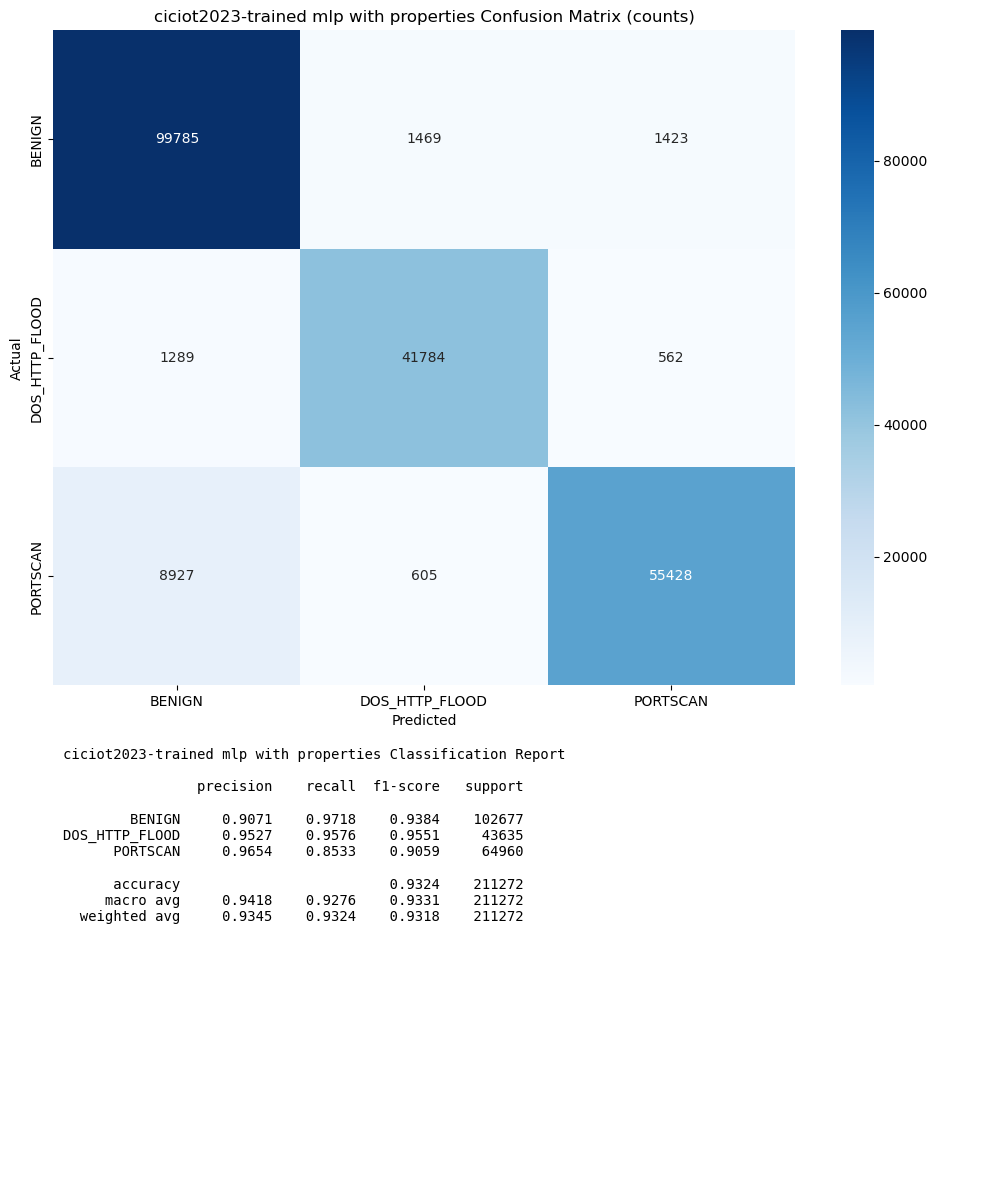

Saved model to: models/mlp_property_ciciot2023.joblib

Saved model to: models/mlp_property_ciciot2023.joblib


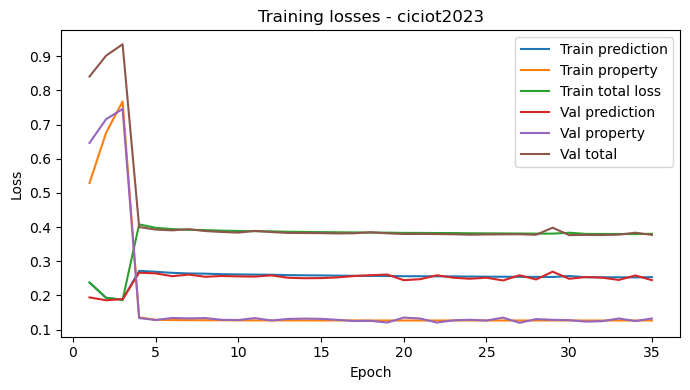

In [16]:
for MODEL_TYPE in MODEL_TYPES:
    for dataset_name, dataset_config in DATASETS.items():
        print("\n" + "=" * 70)
        print(f"TRAINING ON: {dataset_name.upper()}")
        print("=" * 70)

        df_train = dataset_config["data_train"].copy()
        df_test = dataset_config["data_test"].copy()

        X_train = df_train[FEATURES]
        X_test = df_test[FEATURES]
        y_train = df_train["label"]
        y_test = df_test["label"]

        print("Shape:", df_train.shape)
        print(df_train["label"].value_counts())
        print("Features:", len(FEATURES))
        print(FEATURES)

        # ======================================================
        # Labels
        # ======================================================
        label_encoder = LabelEncoder()

        y_train_enc = label_encoder.fit_transform(y_train)
        y_test_enc = label_encoder.transform(y_test)

        X_train_bal = X_train.copy()
        X_test_local = X_test.copy()

        # ======================================================
        # Categorical encoding
        # ======================================================
        categorical_cols = X_train_bal.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
        ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

        if len(categorical_cols) > 0:
            X_train_bal[categorical_cols] = ordinal_encoder.fit_transform(X_train_bal[categorical_cols])
            X_test_local[categorical_cols] = ordinal_encoder.transform(X_test_local[categorical_cols])

        binary_cols = [c for c in PROPERTY_BOOLEAN_FEATURES]
        continuous_cols = [c for c in FEATURES if c not in binary_cols]

        # ======================================================
        # Split columns
        # ======================================================
        binary_cols = [c for c in PROPERTY_BOOLEAN_FEATURES if c in FEATURES]
        continuous_cols = [c for c in FEATURES if c not in binary_cols]
        
        # ======================================================
        # Scale only non-boolean columns
        # ======================================================
        scaler = StandardScaler()
        X_train_scaled_df = X_train_bal.copy()
        X_test_scaled_df = X_test_local.copy()
        

        if len(continuous_cols) > 0:
            X_train_scaled_df[continuous_cols] = scaler.fit_transform(X_train_bal[continuous_cols])
            X_test_scaled_df[continuous_cols] = scaler.transform(X_test_local[continuous_cols])

        X_train_scaled = X_train_scaled_df[FEATURES].values
        X_test_scaled = X_test_scaled_df[FEATURES].values

        # Restore binary columns to original 0/1 values
        for col in binary_cols:
            X_train_scaled_df[col] = X_train_bal[col].values
            X_test_scaled_df[col] = X_test_local[col].values

        # binary_cols are left untouched
        X_train_scaled = X_train_scaled_df[FEATURES].values
        X_test_scaled = X_test_scaled_df[FEATURES].values

        # ======================================================
        # Train / validation split
        # ======================================================
        X_train_part, X_val_part, y_train_part, y_val_part = train_test_split(
            X_train_scaled,
            y_train_enc,
            test_size=0.15,
            random_state=42,
            stratify=y_train_enc,
        )

        # ======================================================
        # Tensors
        # ======================================================
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
        X_val_tensor = torch.tensor(X_val_part, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

        y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
        y_val_tensor = torch.tensor(y_val_part, dtype=torch.long)
        y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

        # ======================================================
        # Model
        # ======================================================
        num_classes = len(label_encoder.classes_)
        model = build_model(
            model_type=MODEL_TYPE,
            n_features=len(FEATURES),
            num_classes=num_classes,
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

        properties = build_properties(
            device=device,
            scaler=scaler,
            feature_names=FEATURES,
            label_encoder=label_encoder,
            logic=pml_logics.DL2()
        )

        x_batch, _ = next(iter(train_loader))
        x_batch = x_batch.to(device)
        total_loss, total_sat, prop_stats = properties.compute_loss(model, x_batch)

        print("Initial property loss: ", total_loss.item())
        print("Initial property sat: ", total_sat.item())
        print("Property stats:", prop_stats)

        # ======================================================
        # Training
        # ======================================================
        history = []

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(NUM_EPOCHS):

            model.train()

            train_pred_losses = []
            train_prop_losses = []
            train_total_losses = []

            last_stats = {}

            for x_batch, y_batch in train_loader:

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                logits = model(x_batch)

                pred_loss = criterion(logits, y_batch)

                prop_loss, prop_sat, prop_stats = properties.compute_loss(
                    model,
                    x_batch,
                )
                prop_loss_scaled = LAMBDA_PROP * prop_loss


                # For the first few epochs, focus on prediction loss to allow the model to learn basic patterns. 
                # After that, start incorporating the property loss to guide the model towards satisfying the properties.
                if epoch < 3:
                    total_loss = pred_loss
                else:
                    total_loss = pred_loss + prop_loss_scaled

                total_loss.backward()
                optimizer.step()

                train_pred_losses.append(pred_loss.item())
                train_prop_losses.append(prop_loss_scaled.item())
                train_total_losses.append(total_loss.item())

                last_stats = prop_stats

            avg_train_pred = float(np.mean(train_pred_losses))
            avg_train_prop = float(np.mean(train_prop_losses))
            avg_train_total = float(np.mean(train_total_losses))

            # ==================================================
            # Validation
            # ==================================================
            model.eval()

            val_pred_losses = []
            val_prop_losses = []
            val_total_losses = []

            with torch.no_grad():
                for x_batch, y_batch in val_loader:

                    x_batch = x_batch.to(device)
                    y_batch = y_batch.to(device)

                    logits = model(x_batch)

                    val_pred = criterion(logits, y_batch)

                    val_prop, _, _ = properties.compute_loss(
                        model,
                        x_batch,
                    )
                    
                    val_prop_scaled = LAMBDA_PROP * val_prop
                    val_total = val_pred + val_prop_scaled

                    val_pred_losses.append(val_pred.item())
                    val_prop_losses.append(val_prop_scaled.item())
                    val_total_losses.append(val_total.item())

            avg_val_pred = float(np.mean(val_pred_losses))
            avg_val_prop = float(np.mean(val_prop_losses))
            avg_val_total = float(np.mean(val_total_losses))

            history.append(
                {
                    "epoch": epoch + 1,
                    "train_pred_loss": avg_train_pred,
                    "train_prop_loss": avg_train_prop,
                    "train_total_loss": avg_train_total,
                    "val_pred_loss": avg_val_pred,
                    "val_prop_loss": avg_val_prop,
                    "val_total_loss": avg_val_total,
                    **last_stats,
                }
            )

            print(
                f"Epoch {epoch+1} | "
                f"train_pred_loss={avg_train_pred:.4f} | "
                f"train_prop_loss={avg_train_prop:.4f} | "
                f"train_total_loss={avg_train_total:.4f} | "
                f"val_pred_loss={avg_val_pred:.4f} | "
                f"val_prop_loss={avg_val_prop:.4f} | "
                f"val_total_loss={avg_val_total:.4f} | "
                f"{', '.join(f'{k}={v:.4f}' for k, v in last_stats.items())}"
            )

            # ==================================================
            # Early stopping
            # ==================================================
            if avg_val_total < best_val_loss - MIN_DELTA:
                best_val_loss = avg_val_total
                best_model_state = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

        # restore best model
        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        # ======================================================
        # Test evaluation
        # ======================================================
        model.eval()
        all_preds = []
        all_true = []

        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)

                logits = model(x_batch)
                preds = torch.argmax(logits, dim=1).cpu().numpy()

                all_preds.extend(preds)
                all_true.extend(y_batch.cpu().numpy())

        y_true_labels = label_encoder.inverse_transform(np.array(all_true))
        y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

        evaluate_model(
            y_true_labels,
            y_pred_labels,
            model_name=f"{dataset_name}-trained {MODEL_TYPE} with properties",
            path_to_save=f"{date.today()}/train_with_properties_evaluation_results"
        )

        os.makedirs("models", exist_ok=True)
        # ======================================================
        # Save model
        # ======================================================
        save_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"

        joblib.dump(
            {
                "model": model.cpu(),
                "ordinal_encoder": ordinal_encoder,
                "scaler": scaler,
                "label_encoder": label_encoder,
                "features": FEATURES,
                "categorical_cols": list(categorical_cols),
                "continuous_cols": list(continuous_cols),
                "binary_cols": list(binary_cols),
                "model_type": MODEL_TYPE,
            },
            save_path,
        )

        print(f"Saved model to: {save_path}")

        print(f"\nSaved model to: {save_path}")

        history_df = pd.DataFrame(history)
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["epoch"],history_df["train_pred_loss"],label="Train prediction")
        plt.plot(history_df["epoch"],history_df["train_prop_loss"],label="Train property")
        plt.plot(history_df["epoch"],history_df["train_total_loss"],label="Train total loss",)
        plt.plot(history_df["epoch"],history_df["val_pred_loss"],label="Val prediction",)
        plt.plot(history_df["epoch"],history_df["val_prop_loss"],label="Val property",)
        plt.plot(history_df["epoch"],history_df["val_total_loss"],label="Val total",)
        
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training losses - {dataset_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Cross-data Eval

In [17]:
df_cicids2017 = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")

In [18]:
df_cicids2017_filtered = filter_labels(df_cicids2017, TARGET_LABELS)
df_ciciot2023_filtered = filter_labels(df_ciciot2023, TARGET_LABELS)

In [19]:
DATASETS_EVAL = {
    "cicids2017": {"X": df_cicids2017_filtered[FEATURES], "y": df_cicids2017_filtered["label"]},
    "ciciot2023": {"X": df_ciciot2023_filtered[FEATURES], "y": df_ciciot2023_filtered["label"]},
}
MODEL_TYPES_EVAL = [ 
    "mlp", 
    # "cnnlstm"
]


EVALUATING CICIOT2023-MLP ON cicids2017

=== CICIOT2023-MLP TESTED ON cicids2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.9955    0.5793    0.7324    625030
DOS_HTTP_FLOOD     0.4954    0.9859    0.6594    147959
      PORTSCAN     0.5719    0.9980    0.7272    154034

      accuracy                         0.7138    927023
     macro avg     0.6876    0.8544    0.7063    927023
  weighted avg     0.8453    0.7138    0.7199    927023

Overall Accuracy: 0.7138

=== Per-Label Accuracy ===

BENIGN: 0.5793
DOS_HTTP_FLOOD: 0.9859
PORTSCAN: 0.9980


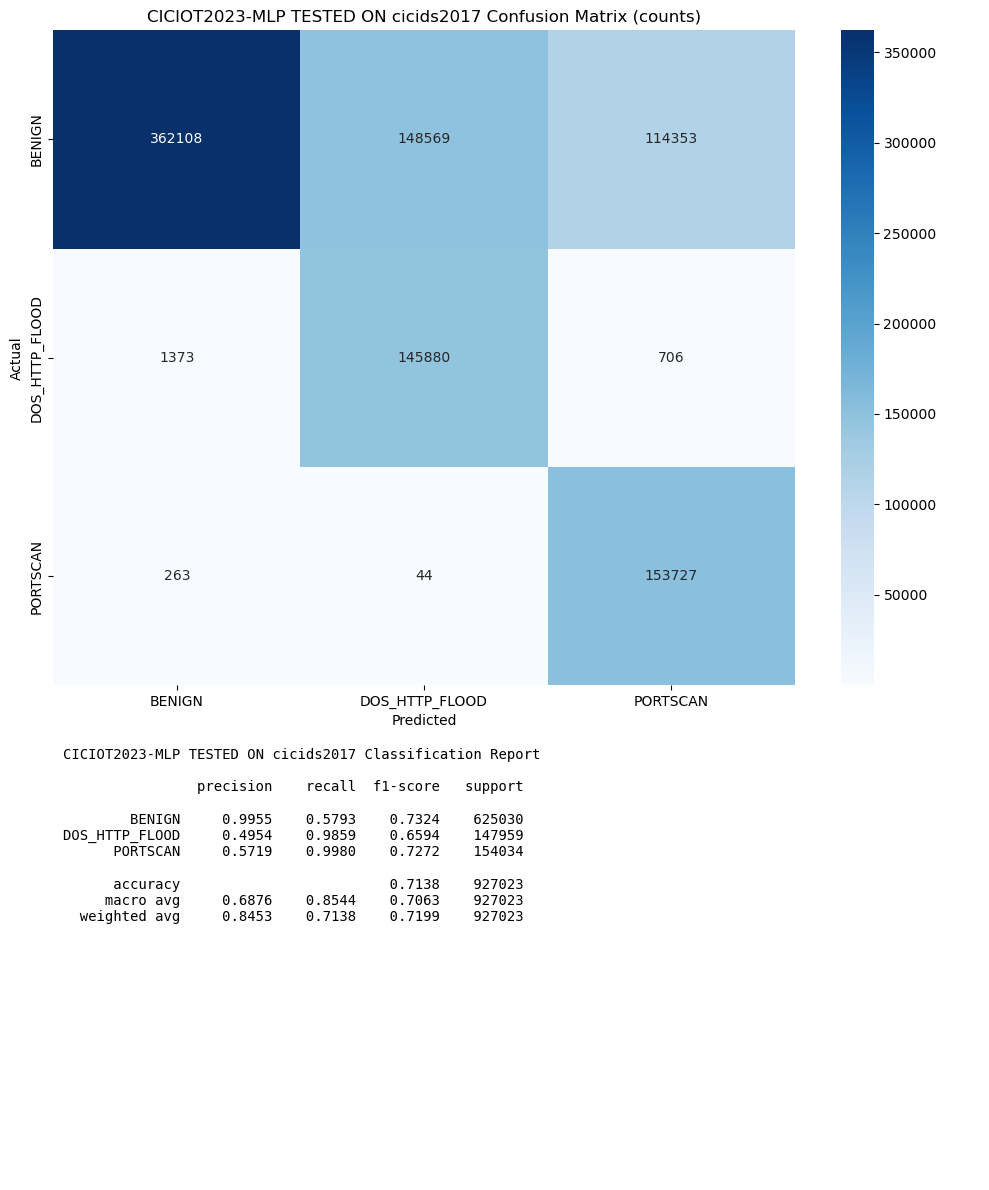

In [21]:
for MODEL_TYPE in MODEL_TYPES_EVAL:
    for train_dataset in DATASETS.keys():
        if train_dataset == "cicids2017":
            test_dataset = "ciciot2023"
        else:
            test_dataset = "cicids2017"

        X_test = DATASETS_EVAL[test_dataset]["X"]
        y_test = DATASETS_EVAL[test_dataset]["y"]
        print("\n" + "=" * 70)
        print(f"EVALUATING {train_dataset.upper()}-{MODEL_TYPE.upper()} ON {test_dataset}")
        print("=" * 70)
        joblib_path = f"models/{MODEL_TYPE}_property_{train_dataset}.joblib"
        load_and_evaluate_model(
            joblib_path=joblib_path,
            X=X_test,
            y_true=y_test,
            model_name=f"{train_dataset.upper()}-{MODEL_TYPE.upper()} TESTED ON {test_dataset}",
            batch_size=1024,
            path_to_save=f"{date.today()}/cross_dataset_evaluation_results",
        )